In [23]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pathlib import Path 
#------------------------------
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb 
from sklearn.metrics import root_mean_squared_error , mean_absolute_error , r2_score 



In [25]:
with open("household_power_consumption.txt", "r") as f:
    for _ in range(6):
        print(repr(f.readline()))

'Date;Time;Global_active_power;Global_reactive_power;Voltage;Global_intensity;Sub_metering_1;Sub_metering_2;Sub_metering_3\n'
'16/12/2006;17:24:00;4.216;0.418;234.840;18.400;0.000;1.000;17.000\n'
'16/12/2006;17:25:00;5.360;0.436;233.630;23.000;0.000;1.000;16.000\n'
'16/12/2006;17:26:00;5.374;0.498;233.290;23.000;0.000;2.000;17.000\n'
'16/12/2006;17:27:00;5.388;0.502;233.740;23.000;0.000;1.000;17.000\n'
'16/12/2006;17:28:00;3.666;0.528;235.680;15.800;0.000;1.000;17.000\n'


In [26]:
BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "household_power_consumption.txt"
df = pd.read_csv(DATA_PATH,sep=';', na_values='?')
df.head(5)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [27]:
df.tail(5)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.0,240.00,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.0,239.70,3.8,0.0,0.0,0.0
2075258,26/11/2010,21:02:00,0.932,0.0,239.55,3.8,0.0,0.0,0.0


In [28]:
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df = df.set_index('datetime')
df.index = pd.to_datetime(df.index)

**Without datetime as the index:** Pandas treats your dataset like a simple table with text, and time-series functions (resample, interpolate('time')) return an error.

**With datetime as the index:** Your DataFrame officially becomes a smart Time Series capable of understanding days, months, and the continuity of time.

In [29]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), str(2)
memory usage: 158.3 MB


In [30]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

#### **Handeling missing values using Interpolation**  
When working with power consumption or IoT metrics:  
**Physical Continuity:** Power usage rarely jumps from $0\text{ kW}$ to $100\text{ kW}$ instantly; it transitions continuously.  
**Preserves Data Length:** Instead of dropping missing rows (which corrupts monthly totals), interpolation fills gaps smoothly.  
**No Artificial Spikes:** Unlike filling missing values with $0$ or the global average, interpolation respects the local context right before and after the gap.  

In [31]:
numeric_cols = ['Global_active_power','Global_reactive_power' , 'Voltage', 'Global_intensity' , 'Sub_metering_1', 'Sub_metering_2' , 'Sub_metering_3'
               ]          
# Apply Time-Based Interpolation to fill the gaps
df[numeric_cols] = df[numeric_cols].interpolate(method='time')

# Handle boundary edge cases (if the very first row is NaN)
df[numeric_cols] = df[numeric_cols].bfill()

In [32]:
df.isnull().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [33]:
print(df.duplicated().sum() )

0


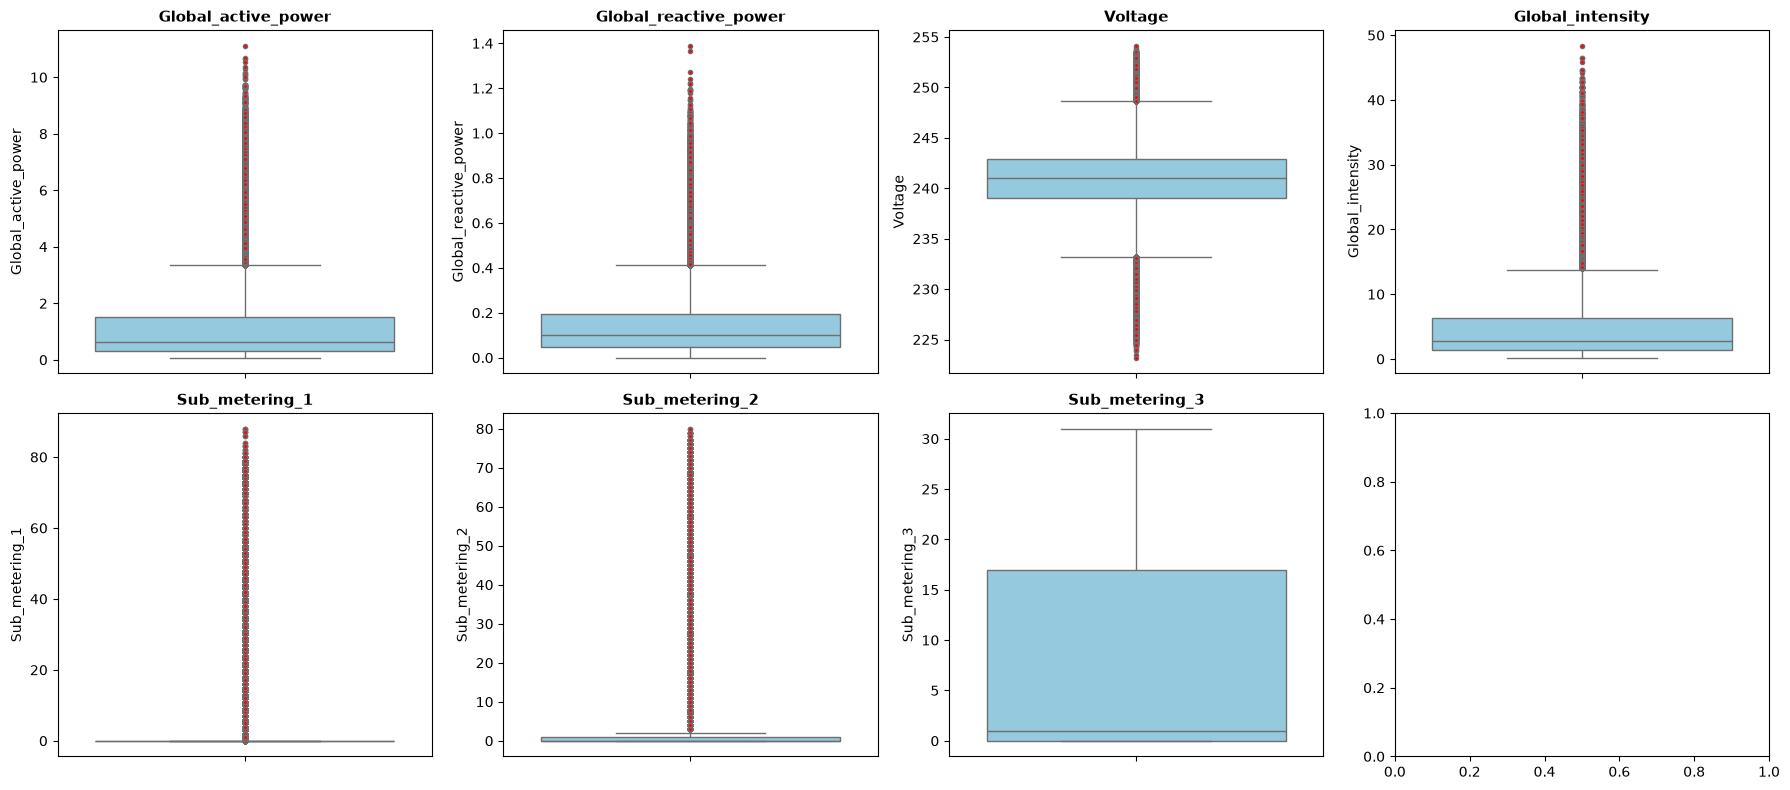

In [34]:
# Plot each feature on its own subplot to avoid scale distortion
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 8))
axes = axes.flatten()

features = [
    'Global_active_power', 'Global_reactive_power', 'Voltage', 
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue', flierprops={'markerfacecolor': 'red', 'markersize': 3})
    axes[i].set_title(col, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

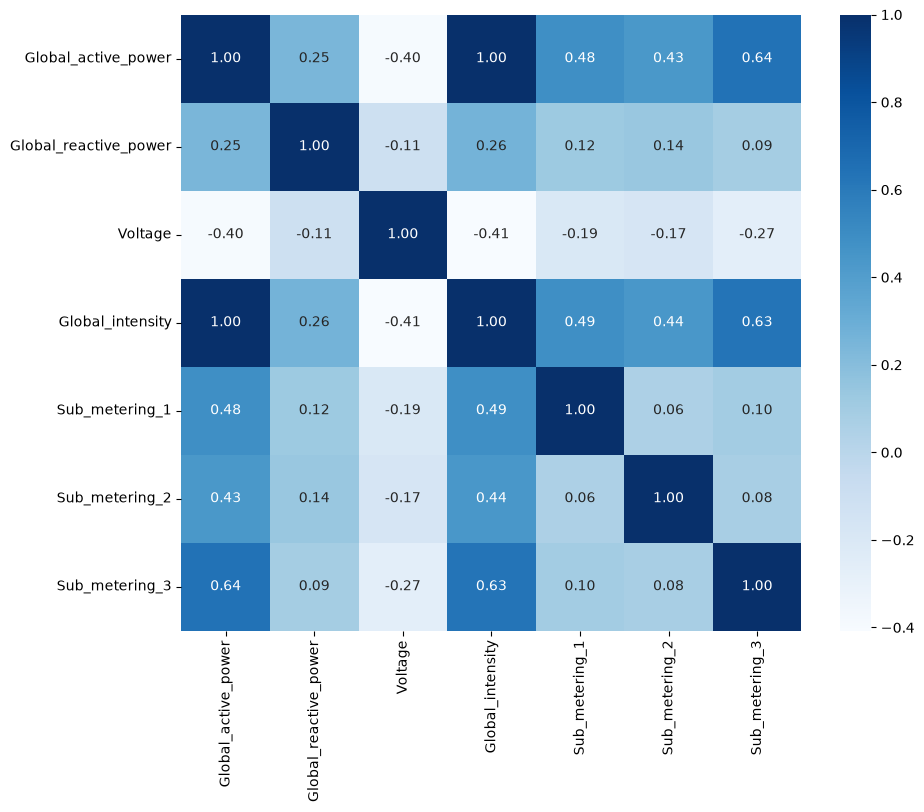

In [35]:
corr = df.corr(numeric_only=True)


plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")
plt.show()

In [36]:
df = df.drop(columns=[ 'Date','Time','Global_reactive_power', 'Voltage', 
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'])
df

,Global_active_power
datetime,
2006-12-16 17:24:00,4.216
2006-12-16 17:25:00,5.360
2006-12-16 17:26:00,5.374
2006-12-16 17:27:00,5.388
2006-12-16 17:28:00,3.666
...,...
2010-11-26 20:58:00,0.946
2010-11-26 20:59:00,0.944
2010-11-26 21:00:00,0.938


In [37]:
def add_monthly_features(df):
    df = df.copy()
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['year'] = df.index.year
    df['lag_1'] = df['Global_active_power'].shift(1)
    df['lag_12'] = df['Global_active_power'].shift(12)
    df = df.dropna()
    
    return df

#--------------------------------------------------------------------------------------------

def add_daily_features(df):
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['dayofyear'] = df.index.dayofyear
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int) 
    df['lag_1'] = df['Global_active_power'].shift(1)
    df['lag_7'] = df['Global_active_power'].shift(7)
    df['lag_364'] = df['Global_active_power'].shift(364)
    df= df.dropna()
    
    return df

 ### **Time Series Cross Validation**


In [38]:
def train_monthly_model(df, target_col='Global_active_power', n_splits=3):
    print("=== ENTRAÎNEMENT DU MODÈLE MENSUEL ('MS') ===")
    
    # Rééchantillonnage mensuel
    df_m = df[target_col].resample('MS').mean().to_frame()
    df_m = add_monthly_features(df_m)
    
    X = df_m.drop(columns=[target_col])
    y = df_m[target_col]
    
    # Cross-Validation : test_size = 6 mois pour s'adapter aux 36 échantillons
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=6, gap=0)
    
    scores = {'mae': [], 'rmse': [], 'r2': []}
    
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Hyperparamètres adaptés à un petit dataset
        model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.03, max_depth=3, random_state=42)
        model.fit(X_train, y_train)
        
        preds = model.predict(X_test)
        
        mae = mean_absolute_error(y_test, preds)
        rmse = root_mean_squared_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        
        scores['mae'].append(mae)
        scores['rmse'].append(rmse)
        scores['r2'].append(r2)
        
        print(f"Fold {fold + 1} -> MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")
        
    print(f"--> Moyennes Mensuelles: MAE={np.mean(scores['mae']):.4f} | RMSE={np.mean(scores['rmse']):.4f} | R²={np.mean(scores['r2']):.4f}\n")
    return model, scores, (X_test, y_test, preds)

In [39]:
def train_model(df, target_col='Global_active_power', n_splits=3, test_size=43200):
    print("=== ENTRAÎNEMENT DU MODÈLE SUR DONNÉES MINUTAIRES (BRUTES) ===")
    
    df_clean = df.copy()
    df_clean = add_monthly_features(df_clean)
    
    X = df_clean.drop(columns=[target_col])
    y = df_clean[target_col]
    
    # test_size = 43 200 minutes = 1 mois par fold
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size, gap=0)
    
    scores = {'mae': [], 'rmse': [], 'r2': []}
    
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Modèle XGBoost
        model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.03, max_depth=3, random_state=42)
        model.fit(X_train, y_train)
        
        preds = model.predict(X_test)
        
        mae = mean_absolute_error(y_test, preds)
        rmse = root_mean_squared_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        
        scores['mae'].append(mae)
        scores['rmse'].append(rmse)
        scores['r2'].append(r2)
        
        print(f"Fold {fold + 1} -> MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")
        
    print(f"--> Moyennes Globale: MAE={np.mean(scores['mae']):.4f} | RMSE={np.mean(scores['rmse']):.4f} | R²={np.mean(scores['r2']):.4f}\n")
    return model, scores, (X_test, y_test, preds)

In [40]:
from sklearn.linear_model import LinearRegression

In [41]:
def train_linear_regression(
    df, target_col="Global_active_power", n_splits=3, test_size=43200
):
    print("=== ENTRAÎNEMENT DU MODÈLE LINEAR REGRESSION ===")

    df_clean = df.copy()
    df_clean = add_monthly_features(df_clean)

    X = df_clean.drop(columns=[target_col])
    y = df_clean[target_col]

   
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size, gap=0)

    scores = {"mae": [], "rmse": [], "r2": []}

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Linear Regression
        model = LinearRegression()
        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        mae = mean_absolute_error(y_test, preds)
        rmse = root_mean_squared_error(y_test, preds)
        r2 = r2_score(y_test, preds)

        scores["mae"].append(mae)
        scores["rmse"].append(rmse)
        scores["r2"].append(r2)

        print(
            f"Fold {fold + 1} -> "
            f"MAE: {mae:.4f} | "
            f"RMSE: {rmse:.4f} | "
            f"R²: {r2:.4f}"
        )

    print(
        f"--> Moyennes Linear Regression: "
        f"MAE={np.mean(scores['mae']):.4f} | "
        f"RMSE={np.mean(scores['rmse']):.4f} | "
        f"R²={np.mean(scores['r2']):.4f}\n"
    )

    return model, scores, (X_test, y_test, preds)

In [42]:
def train_daily_model(df, target_col='Global_active_power', n_splits=3):
    print("=== ENTRAÎNEMENT DU MODÈLE JOURNALIER ('D') ===")
    
    # Rééchantillonnage journalier
    df_d = df[target_col].resample('D').mean().to_frame()
    df_d = add_daily_features(df_d)
    
    X = df_d.drop(columns=[target_col])
    y = df_d[target_col]
    
    # Cross-Validation : test_size = 365 jours (1 an)
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=180, gap=0)
    
    scores = {'mae': [], 'rmse': [], 'r2': []}
    
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Modèle XGBoost
        model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.03, max_depth=3, random_state=42)
        model.fit(X_train, y_train)
        
        preds = model.predict(X_test)
        
        mae = mean_absolute_error(y_test, preds)
        rmse = root_mean_squared_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        
        scores['mae'].append(mae)
        scores['rmse'].append(rmse)
        scores['r2'].append(r2)
        
        print(f"Fold {fold + 1} -> MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")
        
    print(f"--> Moyennes Journalières: MAE={np.mean(scores['mae']):.4f} | RMSE={np.mean(scores['rmse']):.4f} | R²={np.mean(scores['r2']):.4f}\n")
    return model, scores, (X_test, y_test, preds)

In [43]:
# model_mensuel, scores_mensuels, (X_test_m, y_test_m, preds_m) = train_monthly_model(df)
# -------------------------
# model_mensuel, scores_mensuels, (X_test_m, y_test_m, preds_m) = train_daily_model(df)
# --------------------------------
model_mensuel, scores_mensuels, (X_test_m, y_test_m, preds_m) = train_model(df)
model_lr, scores_lr, (X_test_lr, y_test_lr, preds_lr) = train_linear_regression(df)

=== ENTRAÎNEMENT DU MODÈLE SUR DONNÉES MINUTAIRES (BRUTES) ===
Fold 1 -> MAE: 0.0944 | RMSE: 0.2180 | R²: 0.9262
Fold 2 -> MAE: 0.1049 | RMSE: 0.2520 | R²: 0.9345
Fold 3 -> MAE: 0.0936 | RMSE: 0.2317 | R²: 0.9438
--> Moyennes Globale: MAE=0.0976 | RMSE=0.2339 | R²=0.9348

=== ENTRAÎNEMENT DU MODÈLE LINEAR REGRESSION ===
Fold 1 -> MAE: 0.0835 | RMSE: 0.2172 | R²: 0.9268
Fold 2 -> MAE: 0.0932 | RMSE: 0.2488 | R²: 0.9362
Fold 3 -> MAE: 0.0797 | RMSE: 0.2225 | R²: 0.9482
--> Moyennes Linear Regression: MAE=0.0854 | RMSE=0.2295 | R²=0.9371



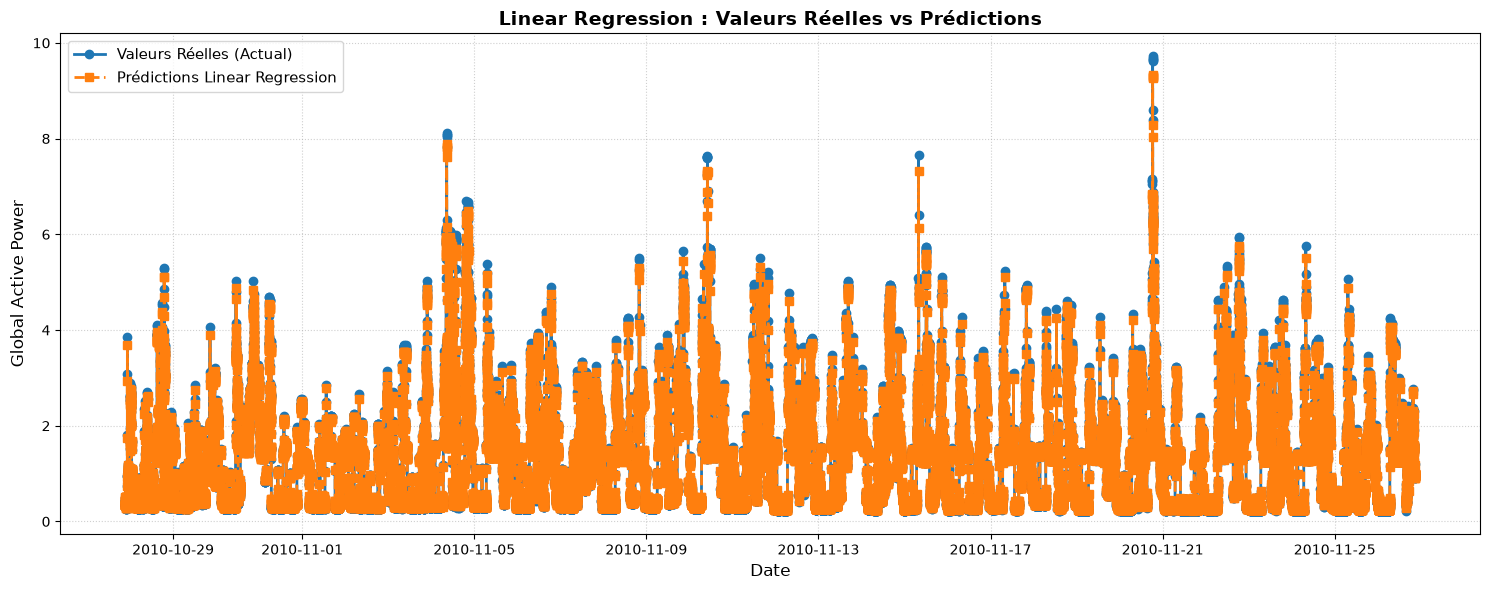

In [44]:
# Configuration du graphique
plt.figure(figsize=(15, 6))

# 1. Courbe des valeurs réelles
plt.plot(
    y_test_lr.index,
    y_test_lr.values,
    label="Valeurs Réelles (Actual)",
    color="#1f77b4",
    linewidth=2,
    marker="o",
)

# 2. Courbe des prédictions Linear Regression
plt.plot(
    y_test_lr.index,
    preds_lr,
    label="Prédictions Linear Regression",
    color="#ff7f0e",
    linewidth=2,
    linestyle="--",
    marker="s",
)

# Mise en forme
plt.title(
    "Linear Regression : Valeurs Réelles vs Prédictions", fontsize=14, fontweight="bold"
)

plt.xlabel("Date", fontsize=12)
plt.ylabel("Global Active Power", fontsize=12)

plt.legend(loc="upper left", fontsize=11)

plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()

# Affichage
plt.show()

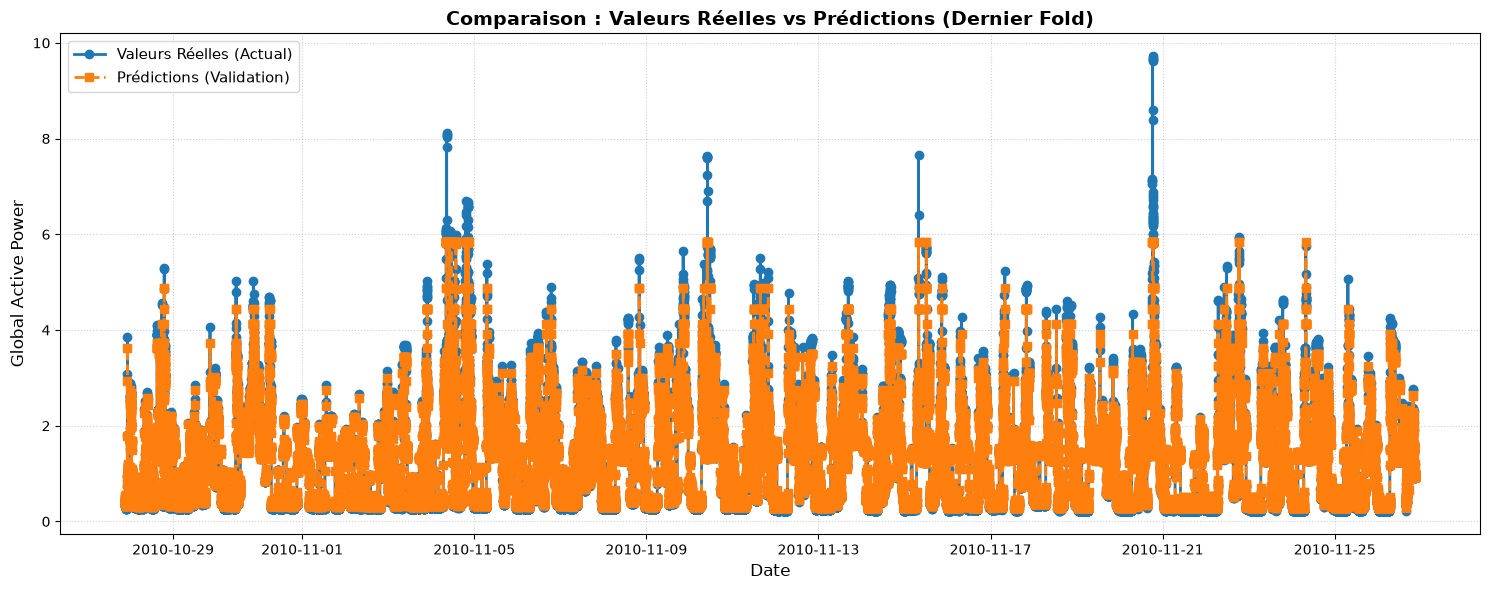

In [45]:

# Configuration du graphique
plt.figure(figsize=(15, 6))

# 1. Courbe des valeurs réelles (Actual)
plt.plot(
    y_test_m.index, 
    y_test_m.values, 
    label='Valeurs Réelles (Actual)', 
    color='#1f77b4', 
    linewidth=2, 
    marker='o'
)

# 2. Courbe des prédictions (Validation/Predicted)
plt.plot(
    y_test_m.index, 
    preds_m, 
    label='Prédictions (Validation)', 
    color='#ff7f0e', 
    linewidth=2, 
    linestyle='--', 
    marker='s'
)

# Mise en forme et habillage
plt.title('Comparaison : Valeurs Réelles vs Prédictions (Dernier Fold)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Global Active Power', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Affichage
plt.show()